# Flagging Vendor Invoices for Manual Review
**Objective:** Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns in order to reduce financial risk and improve operational efficiency.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, make_scorer
from sklearn.model_selection import GridSearchCV

# Load DB URI from .env
load_dotenv()
db_uri = os.getenv("DATABASE_URL")
engine = create_engine(db_uri)

In [7]:
# 1. Purchases Table (Aggregated Data)
# PostgreSQL mein JulianDay ki zaroorat nahi, direct ::date me cast karke subtract kar sakte hain
query_purchases = """
SELECT 
    p."PONumber",
    COUNT(DISTINCT p."Brand") AS "Total_Brands",
    SUM(p."Quantity") AS "Total_Item_Quantity",
    SUM(p."Dollars") AS "Total_Item_Dollars",
    AVG(p."ReceivingDate"::date - p."PODate"::date) AS "Average_Receiving_Delay"
FROM "purchases" p
GROUP BY p."PONumber"
"""
df_purchases = pd.read_sql(query_purchases, engine)

# 2. Vendor Invoices Table
query_invoices = """
SELECT 
    vi."PONumber",
    vi."Quantity" AS "Invoice_Quantity",
    vi."Dollars" AS "Invoice_Dollars",
    vi."Freight",
    (vi."InvoiceDate"::date - vi."PODate"::date) AS "Days_PO_to_Invoice",
    (vi."PayDate"::date - vi."InvoiceDate"::date) AS "Days_to_Pay"
FROM "vendor_invoice" vi
"""
df_invoices = pd.read_sql(query_invoices, engine)

# 3. Merging the datasets on Purchase Order Number
df_merged = pd.merge(df_purchases, df_invoices, on='PONumber', how='inner')
print("Merged Data Shape:", df_merged.shape)
df_merged.head()

Merged Data Shape: (5543, 10)


Merged Data Shape: (5543, 10)


,PONumber,Total_Brands,Total_Item_Quantity,Total_Item_Dollars,Average_Receiving_Delay,Invoice_Quantity,Invoice_Dollars,Freight,Days_PO_to_Invoice,Days_to_Pay
0,8106,81,10100.0,137483.78,12.614130,10100,137483.78,2935.20,23,24
1,8107,2,24.0,348.72,12.500000,24,348.72,9.08,16,36
2,8108,165,8466.0,60281.13,12.632479,8466,60281.13,1549.81,22,30
3,8109,23,2246.0,14298.09,12.626866,2246,14298.09,408.72,23,30
4,8110,183,8086.0,56493.23,12.695271,8086,56493.23,1300.92,20,41


In [16]:
def create_invoice_risk_label(row):
    
    # Invoice total mismatch with item-level total
    if (abs(row["Invoice_Dollars"] - row["Total_Item_Dollars"]) > 5):
        return 1
        
    # Abnormally high receiving delay
    if row["Average_Receiving_Delay"] > 10:
        return 1
        
    return 0

df_merged["Flagged_Invoice"] = df_merged.apply(create_invoice_risk_label, axis=1)
df_merged["Flagged_Invoice"].value_counts()

,count
Flagged_Invoice,
0,3693
1,1850


In [17]:
# hypothesis testing
# Dono groups ko alag karna
flagged = df_merged[df_merged['Flagged_Invoice'] == 1]
normal = df_merged[df_merged['Flagged_Invoice'] == 0]

metrics = [
    'Total_Item_Quantity', 'Total_Item_Dollars', 'Invoice_Quantity',
    'Invoice_Dollars', 'Freight', 'Average_Receiving_Delay',
    'Total_Brands', 'Days_PO_to_Invoice', 'Days_to_Pay'
]

significant_features = []
non_significant_features = []
results = []

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            'metric': metric,
            'flagged_mean': round(flagged_mean, 2),
            'normal_mean': round(normal_mean, 2),
            'p_value': round(p_value, 3)
        })
    else:
        non_significant_features.append(metric)

print(f"Non-Significant Features (To be dropped): {non_significant_features}")

Non-Significant Features (To be dropped): ['Total_Brands', 'Days_to_Pay']


In [18]:
# Drop non-significant features and unneeded IDs
features_to_drop = non_significant_features + ['PONumber', 'Flagged_Invoice']
X = df_merged.drop(columns=features_to_drop)
y = df_merged['Flagged_Invoice']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standard Scaling (Crucial for handling large variations between Dollars and Quantities)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Base Models Testing
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    print(f"\n--- {name} Performance ---")
    print(classification_report(y_test, preds))

# Observation: Random Forest performs the best, so it becomes our base model.


--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.75      0.94      0.83       716
           1       0.80      0.43      0.56       393

    accuracy                           0.76      1109
   macro avg       0.77      0.68      0.70      1109
weighted avg       0.77      0.76      0.74      1109


--- Decision Tree Performance ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       716
           1       0.95      0.93      0.94       393

    accuracy                           0.96      1109
   macro avg       0.95      0.95      0.95      1109
weighted avg       0.96      0.96      0.96      1109


--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       716
           1       1.00      0.91      0.95       393

    accuracy                           0.97      1109
   macro avg     

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Parameters Found: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 3, 'n_estimators': 300}

--- Tuned Random Forest (Final Model) ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       716
           1       1.00      0.92      0.96       393

    accuracy                           0.97      1109
   macro avg       0.98      0.96      0.97      1109
weighted avg       0.97      0.97      0.97      1109



Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Parameters Found: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 3, 'n_estimators': 300}

--- Tuned Random Forest (Final Model) ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       716
           1       1.00      0.92      0.96       393

    accuracy                           0.97      1109
   macro avg       0.98      0.96      0.97      1109
weighted avg       0.97      0.97      0.97      1109



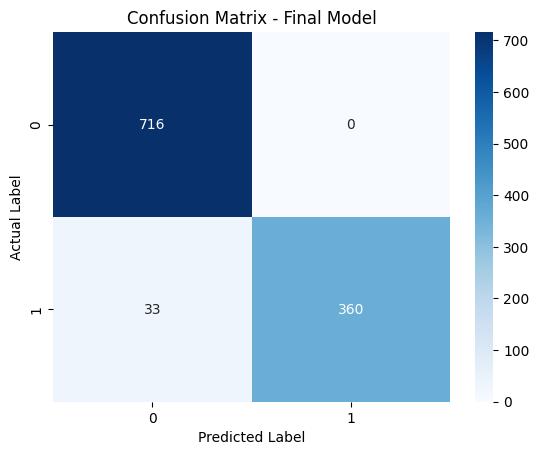

In [19]:
# Tuning Random Forest with GridSearchCV to handle slight class imbalance
rf_classifier = RandomForestClassifier(random_state=42, n_jobs=-1)

# Parameter Grid for experimentation
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 4, 5, 6],
    'min_samples_split': [2, 3, 5],
    'criterion': ['gini', 'entropy']
}

# F1-Score custom scorer (best for imbalanced datasets to balance Precision/Recall)
f1_scorer = make_scorer(f1_score)

# Run GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_classifier, 
    param_grid=param_grid, 
    scoring=f1_scorer, 
    cv=5, 
    n_jobs=-1, 
    verbose=2
)

grid_search.fit(X_train_scaled, y_train)

best_rf_model = grid_search.best_estimator_
print("\nBest Parameters Found:", grid_search.best_params_)

# Final Evaluation of the tuned model
final_preds = best_rf_model.predict(X_test_scaled)
score=f1_score(y_test, final_preds)
print("\n--- Tuned Random Forest (Final Model) ---")
print(classification_report(y_test, final_preds))

# Plotting the Confusion Matrix to see reduced False Positives
sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Final Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()